In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import os
import matplotlib.pyplot as plt

In [18]:
os.makedirs("../results", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

In [22]:
SEED = 1234
REPEATS = 10

In [4]:
df = pd.read_csv("../data/mlc_churn.csv")

df.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,KS,128,area_code_415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,no
1,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,no
2,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,no
3,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,no
4,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,no


In [5]:
print(f"Shape: {df.shape}")
df.info()

Shape: (5000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   state                          5000 non-null   object 
 1   account_length                 5000 non-null   int64  
 2   area_code                      5000 non-null   object 
 3   international_plan             5000 non-null   object 
 4   voice_mail_plan                5000 non-null   object 
 5   number_vmail_messages          5000 non-null   int64  
 6   total_day_minutes              5000 non-null   float64
 7   total_day_calls                5000 non-null   int64  
 8   total_day_charge               5000 non-null   float64
 9   total_eve_minutes              5000 non-null   float64
 10  total_eve_calls                5000 non-null   int64  
 11  total_eve_charge               5000 non-null   float64
 12  total_night_minutes           

In [6]:
print(df['churn'].value_counts())
print()
print(df['churn'].value_counts(normalize=True))

churn
no     4293
yes     707
Name: count, dtype: int64

churn
no     0.8586
yes    0.1414
Name: proportion, dtype: float64


In [7]:
df.isna().sum()

state                            0
account_length                   0
area_code                        0
international_plan               0
voice_mail_plan                  0
number_vmail_messages            0
total_day_minutes                0
total_day_calls                  0
total_day_charge                 0
total_eve_minutes                0
total_eve_calls                  0
total_eve_charge                 0
total_night_minutes              0
total_night_calls                0
total_night_charge               0
total_intl_minutes               0
total_intl_calls                 0
total_intl_charge                0
number_customer_service_calls    0
churn                            0
dtype: int64

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

corr = df[numeric_cols].corr()

corr

,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
account_length,1.000000,-0.014575,-0.001017,0.028240,-0.001019,-0.009591,0.009143,-0.009587,0.000668,-0.007825,0.000656,0.001291,0.014277,0.001292,-0.001445
number_vmail_messages,-0.014575,1.000000,0.005381,0.000883,0.005377,0.019490,-0.003954,0.019496,0.005541,0.002676,0.005535,0.002463,0.000124,0.002505,-0.007086
total_day_minutes,-0.001017,0.005381,1.000000,0.001935,1.000000,-0.010750,0.008128,-0.010760,0.011799,0.004236,0.011783,-0.019486,-0.001303,-0.019415,0.002733
total_day_calls,0.028240,0.000883,0.001935,1.000000,0.001936,-0.000699,0.003754,-0.000695,0.002804,-0.008308,0.002802,0.013097,0.010893,0.013161,-0.010739
total_day_charge,-0.001019,0.005377,1.000000,0.001936,1.000000,-0.010747,0.008129,-0.010757,0.011801,0.004235,0.011785,-0.019490,-0.001307,-0.019419,0.002726
total_eve_minutes,-0.009591,0.019490,-0.010750,-0.000699,-0.010747,1.000000,0.002763,1.000000,-0.016639,0.013420,-0.016642,0.000137,0.008388,0.000159,-0.013823
total_eve_calls,0.009143,-0.003954,0.008128,0.003754,0.008129,0.002763,1.000000,0.002778,0.001781,-0.013682,0.001799,-0.007458,0.005574,-0.007507,0.006235
total_eve_charge,-0.009587,0.019496,-0.010760,-0.000695,-0.010757,1.000000,0.002778,1.000000,-0.016649,0.013422,-0.016652,0.000132,0.008393,0.000155,-0.013836
total_night_minutes,0.000668,0.005541,0.011799,0.002804,0.011801,-0.016639,0.001781,-0.016649,1.000000,0.026972,0.999999,-0.006721,-0.017214,-0.006655,-0.008533
total_night_calls,-0.007825,0.002676,0.004236,-0.008308,0.004235,0.013420,-0.013682,0.013422,0.026972,1.000000,0.026949,0.000391,-0.000156,0.000368,-0.008283


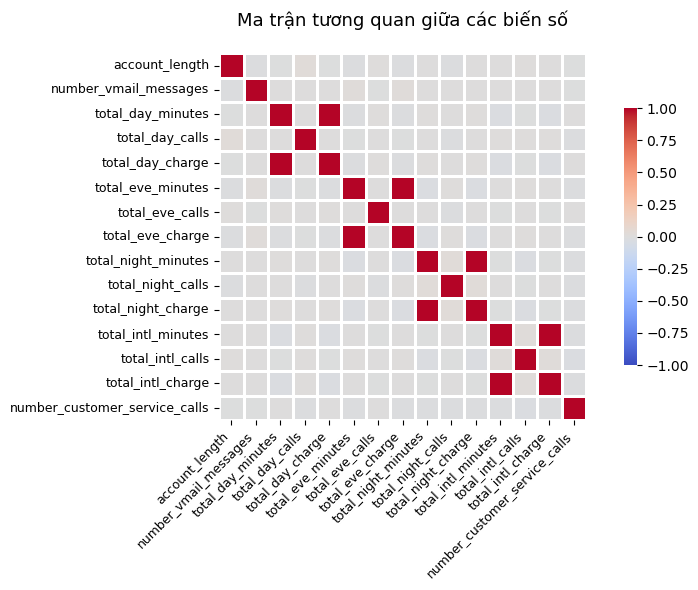

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

ax = sns.heatmap(
    corr, 
    annot=False, 
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    linewidths=0.8, 
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title("Ma trận tương quan giữa các biến số", fontsize=13, pad=20)
plt.tight_layout()
plt.show()

In [10]:
high_corr_pairs = []

for i, col1 in enumerate(numeric_cols):
    for col2 in numeric_cols[i+1:]:
        r = corr.loc[col1, col2]
        if abs(r) >= 0.95:
            high_corr_pairs.append((col1, col2, r))
            
for col1, col2, r in high_corr_pairs:
    print(f"{col1} - {col2}: {r:.6f}")

total_day_minutes - total_day_charge: 1.000000
total_eve_minutes - total_eve_charge: 1.000000
total_night_minutes - total_night_charge: 0.999999
total_intl_minutes - total_intl_charge: 0.999993


In [11]:
drop_cols = [
    "total_day_charge",
    "total_eve_charge",
    "total_night_charge",
    "total_intl_charge"
]

df_model = df.drop(columns=drop_cols)

df_model.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_eve_minutes,total_eve_calls,total_night_minutes,total_night_calls,total_intl_minutes,total_intl_calls,number_customer_service_calls,churn
0,KS,128,area_code_415,no,yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,no
1,OH,107,area_code_415,no,yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,no
2,NJ,137,area_code_415,no,no,0,243.4,114,121.2,110,162.6,104,12.2,5,0,no
3,OH,84,area_code_408,yes,no,0,299.4,71,61.9,88,196.9,89,6.6,7,2,no
4,OK,75,area_code_415,yes,no,0,166.7,113,148.3,122,186.9,121,10.1,3,3,no


In [12]:
X = df_model.drop(columns=['churn'])
y = df_model['churn']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (5000, 15)
y shape: (5000,)


In [13]:
numeric_features = X.select_dtypes(include=[np.number]).columns.to_list()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.to_list()

print(f"Numberic features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Numberic features: ['account_length', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_eve_minutes', 'total_eve_calls', 'total_night_minutes', 'total_night_calls', 'total_intl_minutes', 'total_intl_calls', 'number_customer_service_calls']
Categorical features: ['state', 'area_code', 'international_plan', 'voice_mail_plan']


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

In [19]:
def build_rf_model(max_depth=None, seed=SEED):
    rf = RandomForestClassifier(
        max_depth = max_depth,
        random_state = seed,
        n_jobs = -1,
    )
    
    model = Pipeline(
        steps = [
            ("preprocess", preprocessor),
            ("classifier", rf),
        ]
    )
    
    return model

In [30]:
def evaluate_config_cv(X, y, k, max_depth=None, n_repeats=REPEATS, seed=SEED):
    cv = RepeatedStratifiedKFold(
        n_splits=k,
        n_repeats=n_repeats,
        random_state=seed
    )
    
    fold_rows = []
    
    for split_id, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        repeat_id = (split_id - 1) // k + 1
        fold_id = (split_id - 1) % k + 1
        
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        
        model = build_rf_model(max_depth=max_depth, seed=seed)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        f1 = f1_score(y_test, y_pred, pos_label="yes")
        
        fold_rows.append({
            "repeat": repeat_id,
            "fold": fold_id,
            "k": k,
            "max_depth": "None" if max_depth is None else max_depth,
            "f1": f1
        })
        
    fold_df = pd.DataFrame(fold_rows)
    
    repeat_df = (
        fold_df
        .groupby(["repeat", "k", "max_depth"], as_index=False)
        .agg(f1=("f1", "mean"))
    )
    
    return repeat_df, fold_df
        

In [38]:
from scipy import stats
import numpy as np
import pandas as pd

def mean_ci_table(df, group_cols, value_col="f1", confidence=0.95):
    rows = []

    for group_values, group_df in df.groupby(group_cols):
        values = group_df[value_col].dropna().to_numpy()

        n = len(values)
        mean = np.mean(values)
        sd = np.std(values, ddof=1)
        se = sd / np.sqrt(n)
        t_crit = stats.t.ppf((1 + confidence) / 2, df=n - 1)
        margin = t_crit * se

        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        row = dict(zip(group_cols, group_values))
        row.update({
            "n": n,
            "mean_f1": mean,
            "sd": sd,
            "se": se,
            "ci_lower": mean - margin,
            "ci_upper": mean + margin
        })

        rows.append(row)

    return pd.DataFrame(rows)

## CRD

In [32]:
k_values = [3, 5, 10]

crd_repeat_results = []
crd_fold_details = []

for k in k_values:
    repeat_df, fold_df = evaluate_config_cv(
        X=X,
        y=y,
        k=k,
        max_depth=None,
        n_repeats=REPEATS,
        seed=SEED
    )
    
    crd_repeat_results.append(repeat_df)
    crd_fold_details.append(fold_df)
    
crd_results = pd.concat(crd_repeat_results, ignore_index=True)
crd_fold_details = pd.concat(crd_fold_details, ignore_index=True)

crd_results.head()

,repeat,k,max_depth,f1
0,1,3,None,0.745149
1,2,3,None,0.743740
2,3,3,None,0.738656
3,4,3,None,0.737903
4,5,3,None,0.750037


In [39]:
crd_summary = mean_ci_table(
    crd_results,
    group_cols=["k"]
)

crd_summary

,k,n,mean_f1,sd,se,ci_lower,ci_upper
0,3,10,0.739713,0.007019,0.002220,0.734691,0.744734
1,5,10,0.751997,0.008823,0.002790,0.745685,0.758308
2,10,10,0.754675,0.004038,0.001277,0.751786,0.757564


In [40]:
crd_results.to_csv("../results/crd_results.csv", index=False)
crd_fold_details.to_csv("../results/crd_fold_details.csv", index=False)
crd_summary.to_csv("../results/crd_summary_python.csv", index=False)

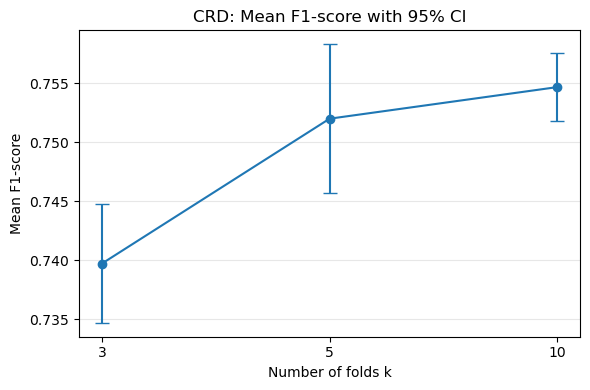

In [42]:
plot_df = crd_summary.sort_values("k")

plt.figure(figsize=(6, 4))

plt.errorbar(
    plot_df["k"].astype(str),
    plot_df["mean_f1"],
    yerr=[
        plot_df["mean_f1"] - plot_df["ci_lower"],
        plot_df["ci_upper"] - plot_df["mean_f1"]
    ],
    fmt="o-",
    capsize=5
)

plt.xlabel("Number of folds k")
plt.ylabel("Mean F1-score")
plt.title("CRD: Mean F1-score with 95% CI")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/crd_mean_ci.png", dpi=300)
plt.show()

## CRFD

In [43]:
k_values = [3, 5, 10]
depth_values = [3, 5, None]

crfd_repeat_results = []
crfd_fold_details = []

for k in k_values:
    for depth in depth_values:
        repeat_df, fold_df = evaluate_config_cv(
            X=X,
            y=y,
            k=k,
            max_depth=depth,
            n_repeats=REPEATS,
            seed=SEED
        )

        crfd_repeat_results.append(repeat_df)
        crfd_fold_details.append(fold_df)

crfd_results = pd.concat(crfd_repeat_results, ignore_index=True)
crfd_fold_details = pd.concat(crfd_fold_details, ignore_index=True)

crfd_results.head()

,repeat,k,max_depth,f1
0,1,3,3,0.000000
1,2,3,3,0.000000
2,3,3,3,0.002825
3,4,3,3,0.002825
4,5,3,3,0.002813


In [44]:
crfd_summary = mean_ci_table(
    crfd_results,
    group_cols=["k", "max_depth"]
)

crfd_summary

,k,max_depth,n,mean_f1,sd,se,ci_lower,ci_upper
0,3,3,10,0.002253,0.001780,0.000563,0.000979,0.003526
1,3,5,10,0.064603,0.009833,0.003109,0.057569,0.071637
2,3,None,10,0.739713,0.007019,0.002220,0.734691,0.744734
3,5,3,10,0.002801,0.001310,0.000414,0.001864,0.003738
4,5,5,10,0.066971,0.006588,0.002083,0.062258,0.071683
5,5,None,10,0.751997,0.008823,0.002790,0.745685,0.758308
6,10,3,10,0.002520,0.000885,0.000280,0.001886,0.003153
7,10,5,10,0.065315,0.008636,0.002731,0.059137,0.071493
8,10,None,10,0.754675,0.004038,0.001277,0.751786,0.757564


In [45]:
crfd_results.to_csv("../results/crfd_results.csv", index=False)
crfd_fold_details.to_csv("../results/crfd_fold_details.csv", index=False)
crfd_summary.to_csv("../results/crfd_summary_python.csv", index=False)

In [47]:
crfd_summary["max_depth"] = crfd_summary["max_depth"].astype(str)

crfd_summary

,k,max_depth,n,mean_f1,sd,se,ci_lower,ci_upper
0,3,3,10,0.002253,0.001780,0.000563,0.000979,0.003526
1,3,5,10,0.064603,0.009833,0.003109,0.057569,0.071637
2,3,None,10,0.739713,0.007019,0.002220,0.734691,0.744734
3,5,3,10,0.002801,0.001310,0.000414,0.001864,0.003738
4,5,5,10,0.066971,0.006588,0.002083,0.062258,0.071683
5,5,None,10,0.751997,0.008823,0.002790,0.745685,0.758308
6,10,3,10,0.002520,0.000885,0.000280,0.001886,0.003153
7,10,5,10,0.065315,0.008636,0.002731,0.059137,0.071493
8,10,None,10,0.754675,0.004038,0.001277,0.751786,0.757564


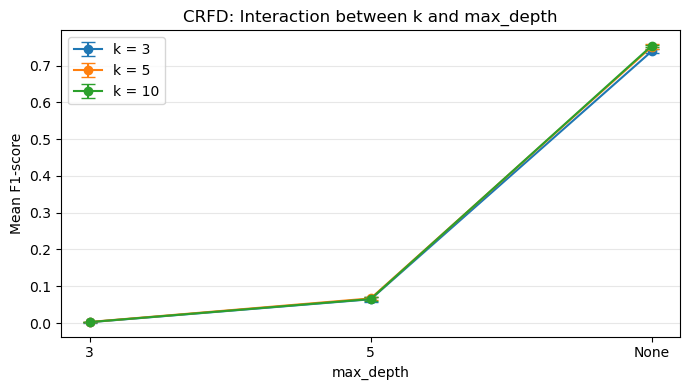

In [48]:
plot_df = crfd_summary.copy()

plot_df["max_depth"] = plot_df["max_depth"].astype(str)

depth_order = ["3", "5", "None"]

plot_df["max_depth"] = pd.Categorical(
    plot_df["max_depth"],
    categories=depth_order,
    ordered=True
)

plot_df = plot_df.sort_values(["k", "max_depth"])

plt.figure(figsize=(7, 4))

for k in sorted(plot_df["k"].unique()):
    sub = plot_df[plot_df["k"] == k]

    plt.errorbar(
        sub["max_depth"].astype(str),
        sub["mean_f1"],
        yerr=[
            sub["mean_f1"] - sub["ci_lower"],
            sub["ci_upper"] - sub["mean_f1"]
        ],
        marker="o",
        capsize=5,
        label=f"k = {k}"
    )

plt.xlabel("max_depth")
plt.ylabel("Mean F1-score")
plt.title("CRFD: Interaction between k and max_depth")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../figures/crfd_interaction.png", dpi=300)
plt.show()